# 실험 3: Setting B — XAI-Enhanced RetinaVLM 추론 (히트맵 이미지 주입)

**IRB 프로토콜 Setting B (XAI-Guided):**
> 원본 OCT 이미지 + XAI 히트맵(Spatial Overlay) + 텍스트 프롬프트 입력

## 입력 구성 (Setting A와의 차이)

| 구분 | Setting A (실험 2) | Setting B (실험 3) |
|------|-------------------|-------------------|
| 이미지 | 원본 OCT | **원본 + GradCAM 히트맵 오버레이** |
| 텍스트 | 기본 query | 기본 query + XAI 텍스트 설명 |
| 목적 | 베이스라인 | XAI가 Attention에 미치는 영향 관찰 |

## 히트맵 주입 방식 (IRB 명시)
1. **Spatial Overlay**: `blended = (1-α)·original + α·heatmap` — 히트맵을 이미지에 alpha-blending
2. **Multiplicative**: `blended = original · (1 + β·heatmap)` — 중요 영역 밝기 증폭

## 평가 항목 (IRB 요구)
- **Attention 히트맵 비교**: Setting A vs B의 LLM Attention 패턴 변화
- **IoU & Pointing Game**: Attention 히트맵 vs Ground Truth 일치도
- **환각(Hallucination) 감소율**: False Positive Rate 비교
- **통계 검정**: paired t-test (IoU 차이의 유의성)

## 파이프라인
```
실험1 GradCAM → 히트맵 오버레이 → RetinaVLM(ResNet→Adapter→LLaMA3) → 리포트 생성
                                    ↓                    ↓
                              ResNet GradCAM       LLM Attention 추출
                                    ↓                    ↓
                              Setting A vs B 비교 → IoU, Pointing Game, 환각률
```

## 1. Imports & Config

In [2]:
import torch
import json
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob
from datetime import datetime
from collections import Counter
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")

# SpecialistVLMs 경로
SPECIALIST_DIR = os.path.abspath("../SpecialistVLMs")
if SPECIALIST_DIR not in sys.path:
    sys.path.insert(0, SPECIALIST_DIR)
os.chdir(SPECIALIST_DIR)

from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir
from models.retinavlm_wrapper import RetinaVLM, RetinaVLMConfig

config_dir = os.path.abspath("configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    config = compose(config_name="default")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. 실험 파라미터

In [3]:
# =====================================================
#  실험 파라미터
# =====================================================

EXP_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments"

# 실험 1 결과 경로 (XAI 이미지 & 매핑)
EXP1_XAI_DIR = os.path.join(EXP_DIR, "exp1_outputs/xai_images")
EXP1_MAPPING = os.path.join(EXP1_XAI_DIR, "xai_mapping.json")

# 실험 2 결과 경로 (Setting A 비교용)
EXP2_RESULTS = os.path.join(EXP_DIR, "exp2_outputs/inference_results.json")
EXP2_ATTN_DIR = os.path.join(EXP_DIR, "exp2_outputs/xai_attention")

# RetinaVLM 체크포인트
SAVE_DIR = "saved_models/RetinaVLM-Specialist-Dequantized"

# 데이터
DATA_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 "

# 추론 설정
MAX_NEW_TOKENS = 300
XAI_METHOD_TO_USE = "gradcam"  # 실험 1의 어떤 XAI 기법을 사용할지

# =====================================================
#  IRB 프로토콜: XAI 히트맵 주입 설정
# =====================================================
OVERLAY_METHOD = "spatial_overlay"  # "spatial_overlay" | "multiplicative"
OVERLAY_ALPHA = 0.4                 # 주입 강도 (0=원본만, 1=히트맵만)
# spatial_overlay: blended = (1-α)·original + α·heatmap_scaled
# multiplicative:  blended = original · (1 + α·heatmap)

# =====================================================
#  IRB 프로토콜: 분류 레이블 설정
# =====================================================
# 현재: OCT2017 데모 데이터 (NORMAL vs CNV)
# 향후: 병원 데이터 (Responder vs Non-responder, CMT/BCVA 기반)
CLASS_NAMES = ["NORMAL", "CNV"]
# CLASS_NAMES = ["Responder", "Non-responder"]  # 향후 데이터

# 출력
OUTPUT_DIR = os.path.join(EXP_DIR, "exp3_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "overlaid_images"), exist_ok=True)

# 실험 1 매핑 로드
assert os.path.exists(EXP1_MAPPING), f"실험 1을 먼저 실행하세요: {EXP1_MAPPING}"
with open(EXP1_MAPPING) as f:
    xai_mapping = json.load(f)
print(f"Loaded {len(xai_mapping)} XAI mappings from Exp 1")
print(f"XAI method: {XAI_METHOD_TO_USE}")
print(f"Overlay: {OVERLAY_METHOD} (alpha={OVERLAY_ALPHA})")
print(f"Output: {OUTPUT_DIR}")

Loaded 100 XAI mappings from Exp 1
XAI method: gradcam
Overlay: spatial_overlay (alpha=0.4)
Output: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs


## 3. XAI 히트맵 오버레이 함수 (IRB: Spatial Overlay / Multiplicative)

실험 1에서 생성한 GradCAM 히트맵을 원본 OCT 이미지에 시각적으로 주입합니다.
이 오버레이된 이미지가 RetinaVLM의 ResNet visual encoder에 입력됩니다.

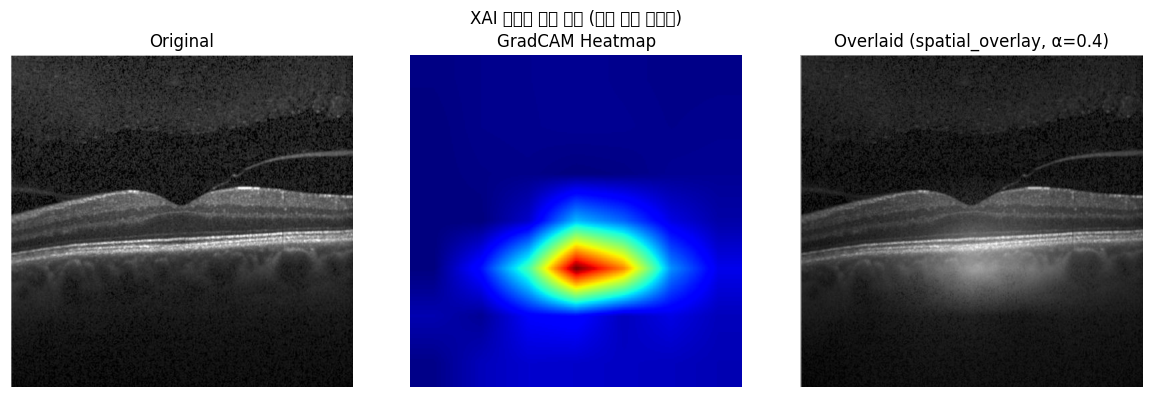

XAI text description (also included in query):
[XAI Analysis] Method: gradcam. The classification model predicted 'NORMAL' (confidence: 100.0%). The gradcam heatmap shows low overall activation (mean=0.093, max=1.000). 4.3% of the image area shows high activation (>0.5 threshold). The most activated regions are: center. This suggests the model focuses on specific localized features in the retinal scan.


In [4]:
def create_xai_overlay(original_img, heatmap_npy_path, method="spatial_overlay", alpha=0.4):
    """XAI 히트맵을 원본 이미지에 오버레이합니다.

    IRB 프로토콜에 따른 두 가지 주입 방식:
      1. Spatial Overlay: blended = (1-α)·original + α·heatmap_scaled
      2. Multiplicative:  blended = original · (1 + α·heatmap)

    Args:
        original_img: numpy grayscale [H, W], uint8 (0-255)
        heatmap_npy_path: .npy 히트맵 경로 (normalized 0-1)
        method: "spatial_overlay" or "multiplicative"
        alpha: 주입 강도

    Returns:
        overlaid_img: numpy grayscale [H, W], uint8 (0-255)
    """
    heatmap = np.load(heatmap_npy_path)  # [h, w], 0-1

    # 히트맵을 원본 이미지 크기로 리사이즈
    heatmap_resized = np.array(
        Image.fromarray(heatmap.astype(np.float32)).resize(
            (original_img.shape[1], original_img.shape[0]), Image.BILINEAR
        )
    )

    # 정규화
    if heatmap_resized.max() > heatmap_resized.min():
        heatmap_resized = (heatmap_resized - heatmap_resized.min()) / \
                          (heatmap_resized.max() - heatmap_resized.min())

    img_f = original_img.astype(np.float32) / 255.0

    if method == "spatial_overlay":
        # Alpha blending: 히트맵 고활성 영역이 밝게 표시
        overlaid = (1 - alpha) * img_f + alpha * heatmap_resized
    elif method == "multiplicative":
        # 곱셈: 중요 영역을 (1+α)배까지 밝게 증폭
        scale = 1.0 + alpha * heatmap_resized
        overlaid = img_f * scale
    else:
        raise ValueError(f"Unknown method: {method}")

    overlaid = np.clip(overlaid * 255, 0, 255).astype(np.uint8)
    return overlaid


def generate_xai_text_description(xai_npy_path, method_name, pred_label, pred_probs):
    """XAI 히트맵에서 텍스트 설명을 자동 생성합니다."""
    cam = np.load(xai_npy_path)

    mean_act = float(cam.mean())
    max_act = float(cam.max())
    high_ratio = float((cam > 0.5).sum() / cam.size)

    h, w = cam.shape
    grid_h, grid_w = h // 3, w // 3
    region_names = [
        "upper-left", "upper-center", "upper-right",
        "middle-left", "center", "middle-right",
        "lower-left", "lower-center", "lower-right",
    ]
    region_activations = []
    for r in range(3):
        for c in range(3):
            region = cam[r*grid_h:(r+1)*grid_h, c*grid_w:(c+1)*grid_w]
            region_activations.append(float(region.mean()))

    sorted_regions = sorted(zip(region_names, region_activations),
                           key=lambda x: x[1], reverse=True)
    top_regions = [r[0] for r in sorted_regions[:3] if r[1] > 0.3]

    if mean_act > 0.4:
        intensity = "high"
    elif mean_act > 0.2:
        intensity = "moderate"
    else:
        intensity = "low"

    text = (
        f"[XAI Analysis] Method: {method_name}. "
        f"The classification model predicted '{pred_label}' "
        f"(confidence: {pred_probs.get(pred_label, 0):.1%}). "
        f"The {method_name} heatmap shows {intensity} overall activation "
        f"(mean={mean_act:.3f}, max={max_act:.3f}). "
        f"{high_ratio:.1%} of the image area shows high activation (>0.5 threshold). "
    )
    if top_regions:
        text += f"The most activated regions are: {', '.join(top_regions)}. "
    text += (
        f"This suggests the model focuses on "
        f"{'specific localized features' if high_ratio < 0.2 else 'broadly distributed features'} "
        f"in the retinal scan."
    )
    return text


def build_enhanced_query(base_query, xai_description):
    """기본 쿼리에 XAI 분석 정보를 추가합니다."""
    return (
        f"{base_query}\n\n"
        f"Additional context from automated image analysis:\n"
        f"{xai_description}\n\n"
        f"Please consider the above XAI analysis findings in your clinical assessment. "
        f"Do the highlighted regions correlate with known pathological features?"
    )


# 오버레이 테스트
if len(xai_mapping) > 0:
    test_entry = xai_mapping[0]
    test_npy = os.path.join(EXP1_XAI_DIR, XAI_METHOD_TO_USE,
                            test_entry["xai_files"][XAI_METHOD_TO_USE].replace(".png", ".npy"))
    if os.path.exists(test_npy):
        test_img_path = os.path.join(DATA_DIR, "test", test_entry["true_label"], test_entry["image"])
        test_img = np.array(Image.open(test_img_path).convert("L"))
        test_overlay = create_xai_overlay(test_img, test_npy, OVERLAY_METHOD, OVERLAY_ALPHA)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(test_img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
        axes[1].imshow(np.load(test_npy), cmap="jet"); axes[1].set_title("GradCAM Heatmap"); axes[1].axis("off")
        axes[2].imshow(test_overlay, cmap="gray"); axes[2].set_title(f"Overlaid ({OVERLAY_METHOD}, α={OVERLAY_ALPHA})"); axes[2].axis("off")
        plt.suptitle("XAI 히트맵 주입 결과 (모델 입력 이미지)", fontsize=12)
        plt.tight_layout(); plt.show()

        sample_text = generate_xai_text_description(
            test_npy, XAI_METHOD_TO_USE,
            test_entry.get("pred_label", "unknown"),
            test_entry.get("pred_probs", {})
        )
        print("XAI text description (also included in query):")
        print(sample_text)

## 4. RetinaVLM 모델 로드

In [5]:
# Method 1: Dequantized
rvlm_config = RetinaVLMConfig.from_pretrained(
    "RobbieHolland/RetinaVLM", subfolder="RetinaVLM-Specialist"
)
rvlm_config.update(config)
rvlm_config.model.checkpoint_path = None

print("Creating RetinaVLM model...")
model = RetinaVLM(rvlm_config)

print("Loading dequantized checkpoint...")
state_dict = torch.load(os.path.join(SAVE_DIR, "model.pt"), map_location="cpu")
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"  Loaded: {len(state_dict) - len(unexpected)} keys | "
      f"Missing: {len(missing)} | Unexpected: {len(unexpected)}")
del state_dict

model.to(DEVICE)
model.eval()
print(f"RetinaVLM ready on {DEVICE}")

`torch_dtype` is deprecated! Use `dtype` instead!


Creating RetinaVLM model...
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


Loading weights: 100%|██████████| 291/291 [00:01<00:00, 182.86it/s]


Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)
Loading dequantized checkpoint...
  Loaded: 1220 keys | Missing: 0 | Unexpected: 0
RetinaVLM ready on cuda


## 5. Setting B 추론: 히트맵 오버레이 이미지 + XAI 텍스트 쿼리

**핵심 변경 (vs Setting A):**
- 이미지: `원본 OCT` → `원본 + GradCAM 히트맵 오버레이`
- 텍스트: `기본 query` → `기본 query + XAI 텍스트 설명`

이렇게 하면 ResNet visual encoder가 히트맵이 강조한 영역의 feature를
더 강하게 추출하여, LLM의 Attention이 실제 병변 위치에 집중하는 효과를 기대합니다.

Running Setting B inference on 100 images...
  Image input: original + gradcam overlay (spatial_overlay, α=0.4)
  Text input:  base query + XAI text description
------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 228, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  [1/100] NORMAL-1017237-1.jpeg... | NORMAL | 84 words | 4.1s | overlay=True
Inputs torch.Size([1, 228, 4096])


...

Inputs torch.Size([1, 229, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 229, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 229, 4096])
  [100/100] CNV-933576-4.jpeg... | CNV | 104 words | 2.7s | overlay=True
------------------------------------------------------------
Total: 100 images
Results saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/


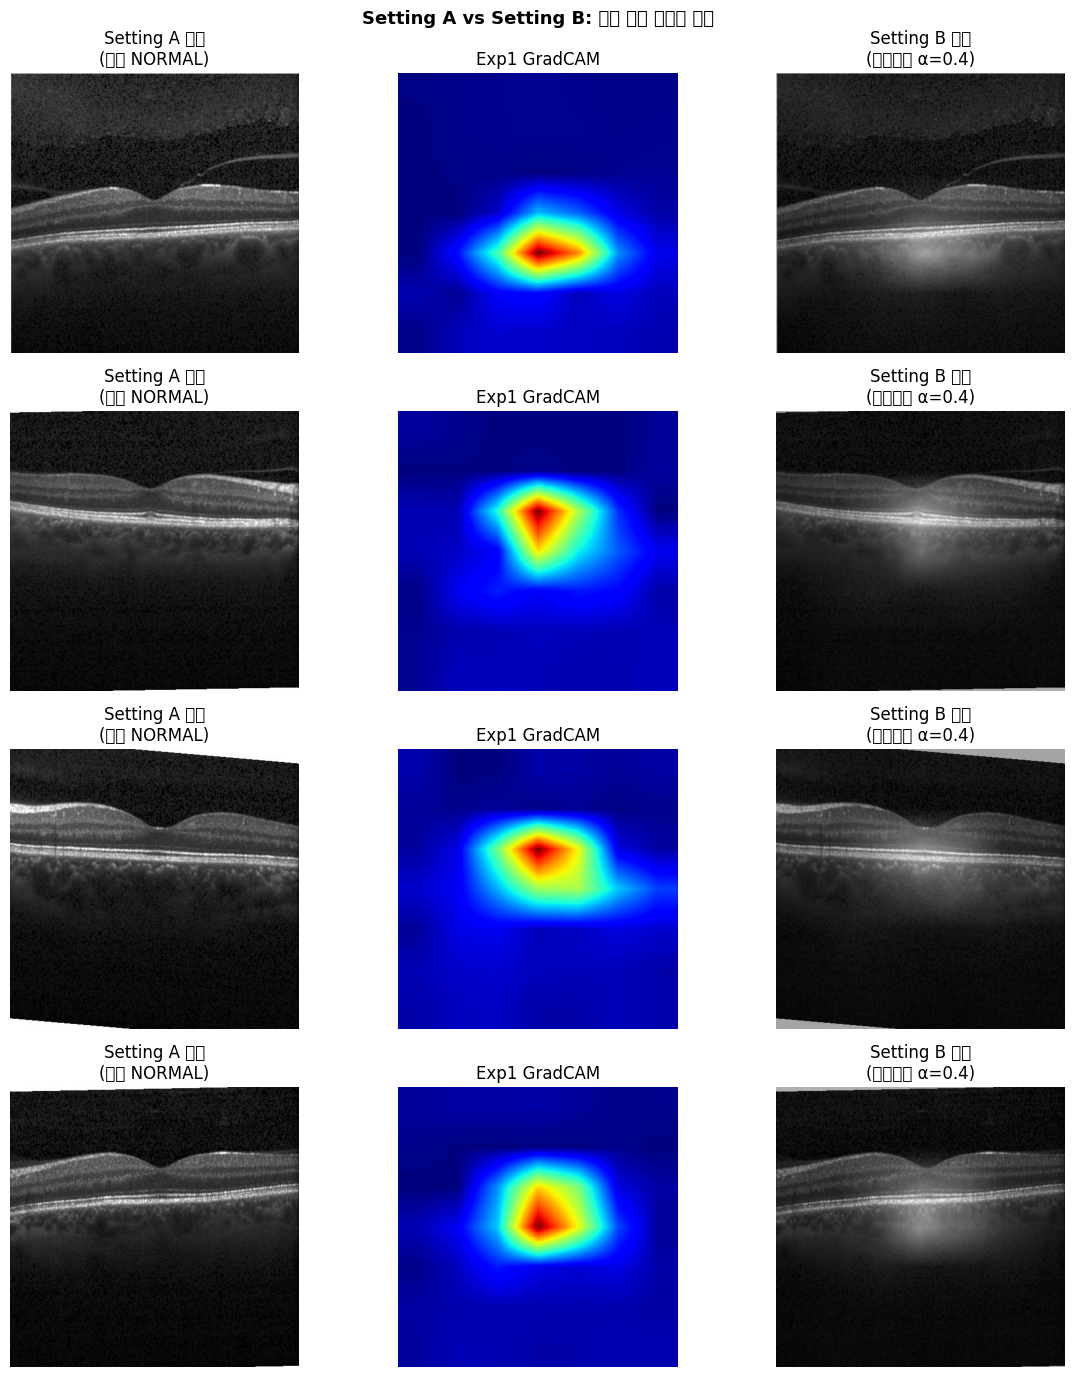

In [6]:
base_query = ("Write a detailed clinical report describing this OCT scan. "
              "Identify any visible biomarkers such as drusen, fluid, or atrophy.")

results_enhanced = []
overlay_log = []

print(f"Running Setting B inference on {len(xai_mapping)} images...")
print(f"  Image input: original + {XAI_METHOD_TO_USE} overlay ({OVERLAY_METHOD}, α={OVERLAY_ALPHA})")
print(f"  Text input:  base query + XAI text description")
print("-" * 60)

for i, entry in enumerate(xai_mapping):
    img_name = entry["image"]
    true_cls = entry["true_label"]

    img_path = os.path.join(DATA_DIR, "test", true_cls, img_name)
    if not os.path.exists(img_path):
        continue

    original_image = np.array(Image.open(img_path).convert("L"))

    # ========== 1) XAI 히트맵 오버레이 (IRB Setting B 핵심) ==========
    npy_path = os.path.join(EXP1_XAI_DIR, XAI_METHOD_TO_USE,
                            entry["xai_files"][XAI_METHOD_TO_USE].replace(".png", ".npy"))

    if os.path.exists(npy_path):
        # 히트맵을 이미지에 오버레이 → 모델 입력 이미지
        overlaid_image = create_xai_overlay(original_image, npy_path, OVERLAY_METHOD, OVERLAY_ALPHA)
        overlay_applied = True

        # XAI 텍스트 설명 생성 → 쿼리에 추가
        xai_text = generate_xai_text_description(
            npy_path, XAI_METHOD_TO_USE,
            entry.get("pred_label", "unknown"),
            entry.get("pred_probs", {})
        )
    else:
        overlaid_image = original_image
        xai_text = "[XAI data not available]"
        overlay_applied = False

    enhanced_query = build_enhanced_query(base_query, xai_text)

    # ========== 2) 추론: 오버레이 이미지 + Enhanced 쿼리 ==========
    start = time.time()
    with torch.no_grad():
        outputs = model.forward([overlaid_image], [enhanced_query], max_new_tokens=MAX_NEW_TOKENS)
    elapsed = time.time() - start

    results_enhanced.append({
        "image": img_name,
        "class": true_cls,
        "response": outputs[0],
        "n_words": len(outputs[0].split()),
        "time_sec": round(elapsed, 2),
        "xai_method": XAI_METHOD_TO_USE,
        "overlay_method": OVERLAY_METHOD,
        "overlay_alpha": OVERLAY_ALPHA,
        "overlay_applied": overlay_applied,
        "xai_text": xai_text,
        "query": enhanced_query,
    })

    # 오버레이 이미지 저장 (처음 10장)
    if i < 10 and overlay_applied:
        fname_base = os.path.splitext(img_name)[0]
        save_path = os.path.join(OUTPUT_DIR, "overlaid_images", f"{fname_base}_overlaid.png")
        Image.fromarray(overlaid_image).save(save_path)
        overlay_log.append({"image": img_name, "overlay_path": save_path})

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  [{i+1}/{len(xai_mapping)}] {img_name[:35]}... | {true_cls} | "
              f"{len(outputs[0].split())} words | {elapsed:.1f}s | overlay={overlay_applied}")

print("-" * 60)
print(f"Total: {len(results_enhanced)} images")

# 저장
with open(os.path.join(OUTPUT_DIR, "enhanced_results.json"), "w") as f:
    json.dump(results_enhanced, f, indent=2, ensure_ascii=False)
df_enhanced = pd.DataFrame(results_enhanced)
df_enhanced.to_csv(os.path.join(OUTPUT_DIR, "enhanced_results.csv"), index=False)
with open(os.path.join(OUTPUT_DIR, "overlay_log.json"), "w") as f:
    json.dump(overlay_log, f, indent=2)
print(f"Results saved to {OUTPUT_DIR}/")

# 오버레이 이미지 비교 시각화
if overlay_log:
    n_show = min(4, len(overlay_log))
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    for j in range(n_show):
        entry = xai_mapping[j]
        img_path = os.path.join(DATA_DIR, "test", entry["true_label"], entry["image"])
        orig = np.array(Image.open(img_path).convert("L"))
        npy_p = os.path.join(EXP1_XAI_DIR, XAI_METHOD_TO_USE,
                             entry["xai_files"][XAI_METHOD_TO_USE].replace(".png", ".npy"))
        ovl = create_xai_overlay(orig, npy_p, OVERLAY_METHOD, OVERLAY_ALPHA)

        axes[j, 0].imshow(orig, cmap="gray"); axes[j, 0].set_title(f"Setting A 입력\n(원본 {entry['true_label']})"); axes[j, 0].axis("off")
        axes[j, 1].imshow(np.load(npy_p), cmap="jet"); axes[j, 1].set_title(f"Exp1 GradCAM"); axes[j, 1].axis("off")
        axes[j, 2].imshow(ovl, cmap="gray"); axes[j, 2].set_title(f"Setting B 입력\n(오버레이 α={OVERLAY_ALPHA})"); axes[j, 2].axis("off")
    plt.suptitle("Setting A vs Setting B: 모델 입력 이미지 비교", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

## 6. 실험 2 vs 실험 3 비교 분석

In [7]:
# 실험 2 결과 로드
if os.path.exists(EXP2_RESULTS):
    with open(EXP2_RESULTS) as f:
        results_baseline = json.load(f)
    print(f"Loaded {len(results_baseline)} baseline results from Exp 2")
else:
    results_baseline = []
    print("WARNING: Exp 2 results not found. Run Experiment 2 first.")

# 비교 분석
BIOMARKERS = [
    "drusen", "fluid", "subretinal fluid", "intraretinal fluid",
    "PED", "atrophy", "RPE atrophy", "SHRM", "ERM", "edema",
    "CNV", "choroidal neovascularization", "hypertransmission",
    "AMD", "normal", "healthy",
]

def count_keywords(results_list, keywords):
    counts = Counter()
    for r in results_list:
        text = r["response"].lower()
        for kw in keywords:
            if kw.lower() in text:
                counts[kw] += 1
    return counts

if results_baseline:
    # 같은 이미지끼리 매칭
    baseline_by_img = {r["image"]: r for r in results_baseline}
    enhanced_by_img = {r["image"]: r for r in results_enhanced}
    common_imgs = set(baseline_by_img.keys()) & set(enhanced_by_img.keys())

    print(f"\nCommon images for comparison: {len(common_imgs)}")

    if common_imgs:
        baseline_common = [baseline_by_img[img] for img in common_imgs]
        enhanced_common = [enhanced_by_img[img] for img in common_imgs]

        kw_baseline = count_keywords(baseline_common, BIOMARKERS)
        kw_enhanced = count_keywords(enhanced_common, BIOMARKERS)

        print(f"\n{'Keyword':<40s} {'Baseline':>10s} {'Enhanced':>10s} {'Diff':>8s}")
        print("-" * 70)
        all_kws = set(list(kw_baseline.keys()) + list(kw_enhanced.keys()))
        for kw in sorted(all_kws, key=lambda k: kw_enhanced.get(k, 0), reverse=True):
            b = kw_baseline.get(kw, 0)
            e = kw_enhanced.get(kw, 0)
            diff = e - b
            sign = "+" if diff > 0 else ""
            print(f"  {kw:<38s} {b:>10d} {e:>10d} {sign}{diff:>7d}")

        # 응답 길이 비교
        avg_words_b = np.mean([r["n_words"] for r in baseline_common])
        avg_words_e = np.mean([r["n_words"] for r in enhanced_common])
        print(f"\nAvg words: Baseline={avg_words_b:.1f}, Enhanced={avg_words_e:.1f}")
else:
    print("\nSkipping comparison (Exp 2 results not available)")

Loaded 50 baseline results from Exp 2

Common images for comparison: 12

Keyword                                    Baseline   Enhanced     Diff
----------------------------------------------------------------------
  atrophy                                        12         10      -2
  drusen                                         12         10      -2
  fluid                                          12         10      -2
  normal                                         11          9      -2
  healthy                                         7          6      -1
  AMD                                             3          5 +      2
  CNV                                             0          4 +      4
  choroidal neovascularization                    0          1 +      1
  ERM                                             0          1 +      1
  RPE atrophy                                     1          0      -1
  intraretinal fluid                              4          0      -4

## 7. 개별 비교 (Baseline vs Enhanced)

In [8]:
# 같은 이미지에 대한 응답 나란히 비교
if results_baseline and common_imgs:
    n_compare = min(5, len(common_imgs))
    compare_imgs = list(common_imgs)[:n_compare]

    for img_name in compare_imgs:
        b = baseline_by_img[img_name]
        e = enhanced_by_img[img_name]

        print(f"\n{'='*70}")
        print(f"Image: {img_name} | Class: {b.get('class', e.get('class', '?'))}")
        print(f"{'='*70}")
        print(f"\n[Baseline Response] ({b['n_words']} words)")
        print(f"  {b['response'][:300]}...")
        print(f"\n[Enhanced Response] ({e['n_words']} words)")
        print(f"  {e['response'][:300]}...")
        print()


Image: CNV-1130960-1.jpeg | Class: CNV

[Baseline Response] (82 words)
  The OCT scan shows a relatively normal appearing retina with no significant signs of disease. The retinal pigment epithelium (RPE) and the photoreceptor layer appear intact. There is no evidence of subretinal or intraretinal fluid, and no signs of atrophy or drusen. The foveal contour is normal, and...

[Enhanced Response] (107 words)
  Based on the XAI analysis, the model has identified specific regions of high activation in the retinal OCT image, which suggests the presence of a complex structure or feature. The most activated regions are centered and in the lower-center of the image. This may indicate the presence of a choroidal...


Image: CNV-1188386-2.jpeg | Class: CNV

[Baseline Response] (39 words)
  The OCT image shows a large central drusen and subretinal fluid. The presence of subretinal fluid suggests active wet AMD. The image also shows RPE irregularities and hypertransmission, indicating RPE atrophy

## 8. ResNet GradCAM + LLM Attention (Setting B: 오버레이 이미지 입력)

Setting B에서는 **오버레이된 이미지**가 모델에 입력됩니다.
따라서 ResNet GradCAM과 LLM Attention 모두 오버레이 이미지 기준으로 추출합니다.
실험 2 (Setting A)의 원본 이미지 Attention과 비교하여 XAI 주입 효과를 분석합니다.

In [9]:
# =====================================================
# ResNet GradCAM + LLM Attention (Setting B: 오버레이 이미지)
# =====================================================

import scipy.ndimage

inner = model.model  # MiniGPT4 instance
llm_hf = inner.llama_model  # HuggingFace LlamaForCausalLM

# --- sdpa → eager 전환 ---
llm_hf.config._attn_implementation = "eager"
for layer in llm_hf.model.layers:
    layer.self_attn._attn_implementation = "eager"
print("Switched LLM attention to 'eager' mode")

# --- 출력 디렉토리 ---
os.makedirs(os.path.join(OUTPUT_DIR, "xai_resnet"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "xai_attention"), exist_ok=True)

# --- 이미지 전처리 ---
def prepare_image_tensor(img_np, device, dtype):
    if img_np.ndim == 2:
        img_np = img_np[np.newaxis, :, :]
    if img_np.shape[1] != 192 or img_np.shape[2] != 192:
        zoom_factors = [1, 192 / img_np.shape[1], 192 / img_np.shape[2]]
        img_np = scipy.ndimage.zoom(img_np, zoom_factors, order=1)
    if not np.issubdtype(img_np.dtype, np.floating):
        img_np = img_np.astype(np.float32) / 255.0
    return torch.from_numpy(img_np).unsqueeze(0).to(device=device, dtype=dtype)

# --- GradCAM hook 설정 ---
gradcam_data = {"activations": None, "gradients": None}

def save_act(m, i, o):
    gradcam_data["activations"] = o.detach()

def save_grad(m, gi, go):
    gradcam_data["gradients"] = go[0].detach()

target_layer = inner.visual_encoder.model.layer4
hook_fwd = target_layer.register_forward_hook(save_act)
hook_bwd = target_layer.register_full_backward_hook(save_grad)

model_param = next(inner.parameters())
model_dtype = model_param.dtype
model_device = model_param.device

n_xai = min(10, len(xai_mapping))
xai_results_exp3 = []

print(f"\nGenerating ResNet GradCAM + LLM Attention for {n_xai} images")
print(f"  Input: 오버레이 이미지 ({OVERLAY_METHOD}, α={OVERLAY_ALPHA})")
print("-" * 60)

for idx in range(n_xai):
    entry = xai_mapping[idx]
    img_name = entry["image"]
    true_cls = entry["true_label"]
    fname_base = os.path.splitext(img_name)[0]

    img_path = os.path.join(DATA_DIR, "test", true_cls, img_name)
    if not os.path.exists(img_path):
        continue

    # ========== 오버레이 이미지 생성 (Setting B) ==========
    original_img = np.array(Image.open(img_path).convert("L"))
    npy_path = os.path.join(EXP1_XAI_DIR, XAI_METHOD_TO_USE,
                            entry["xai_files"][XAI_METHOD_TO_USE].replace(".png", ".npy"))

    if os.path.exists(npy_path):
        overlaid_img = create_xai_overlay(original_img, npy_path, OVERLAY_METHOD, OVERLAY_ALPHA)
        xai_text = generate_xai_text_description(
            npy_path, XAI_METHOD_TO_USE,
            entry.get("pred_label", "unknown"),
            entry.get("pred_probs", {})
        )
    else:
        overlaid_img = original_img
        xai_text = "[XAI data not available]"

    enhanced_query = build_enhanced_query(base_query, xai_text)

    # 오버레이 이미지를 텐서로 변환
    img_tensor = prepare_image_tensor(overlaid_img, model_device, model_dtype)

    result_entry = {"image": fname_base, "class": true_cls}

    # ========== 1) ResNet GradCAM (오버레이 이미지) ==========
    try:
        img_grad = img_tensor.clone().requires_grad_(True)
        backbone = inner.visual_encoder.model
        x = backbone.conv1(img_grad)
        x = backbone.bn1(x)
        x = backbone.relu(x)
        x = backbone.maxpool(x)
        x = backbone.layer1(x)
        x = backbone.layer2(x)
        x = backbone.layer3(x)
        x = backbone.layer4(x)

        target = x.mean()
        target.backward()

        if gradcam_data["gradients"] is not None and gradcam_data["activations"] is not None:
            grads = gradcam_data["gradients"]
            acts = gradcam_data["activations"]
            weights = grads.mean(dim=(2, 3), keepdim=True)
            cam = F.relu((weights * acts).sum(dim=1, keepdim=True))
            cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
            cam = cam.squeeze().cpu().detach().numpy()
            if cam.max() > 0:
                cam = (cam - cam.min()) / (cam.max() - cam.min())

            save_path_gc = os.path.join(OUTPUT_DIR, "xai_resnet", f"{fname_base}_resnet_gradcam.png")
            np.save(save_path_gc.replace(".png", ".npy"), cam)

            display_img = np.array(Image.fromarray(overlaid_img).resize((224, 224)))
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(display_img, cmap="gray"); axes[0].set_title(f"{true_cls} (Overlaid)"); axes[0].axis("off")
            axes[1].imshow(cam, cmap="jet"); axes[1].set_title("ResNet GradCAM"); axes[1].axis("off")
            axes[2].imshow(display_img, cmap="gray")
            axes[2].imshow(cam, cmap="jet", alpha=0.5)
            axes[2].set_title("GradCAM Overlay"); axes[2].axis("off")
            plt.tight_layout(); plt.savefig(save_path_gc, dpi=100, bbox_inches="tight"); plt.close()
            result_entry["resnet_gradcam"] = save_path_gc

        inner.zero_grad()
    except Exception as e:
        print(f"  [{idx+1}] GradCAM error: {e}")

    # ========== 2) LLM Attention (오버레이 이미지 + Enhanced 쿼리) ==========
    try:
        with torch.no_grad():
            samples, tokens, subseq_indices, seq_attentions, _ = inner.attention(
                img_tensor, [enhanced_query]
            )

        pre_len, img_len, post_len = subseq_indices[0]
        text_to_img_attn = seq_attentions[:, 0, :, pre_len + img_len:, pre_len:pre_len + img_len]
        avg_attn = text_to_img_attn.mean(dim=(0, 1, 2)).numpy()

        spatial_size = int(np.sqrt(img_len))
        if spatial_size * spatial_size == img_len:
            attn_map = avg_attn.reshape(spatial_size, spatial_size)
        else:
            attn_map = avg_attn[:spatial_size * spatial_size].reshape(spatial_size, spatial_size)

        if attn_map.max() > attn_map.min():
            attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

        attn_upscaled = np.array(Image.fromarray(attn_map.astype(np.float32)).resize(
            (224, 224), Image.BILINEAR))

        save_path_attn = os.path.join(OUTPUT_DIR, "xai_attention", f"{fname_base}_llm_attention.png")
        npy_path_attn = os.path.join(OUTPUT_DIR, "xai_attention", f"{fname_base}_llm_attention.npy")

        display_img = np.array(Image.fromarray(overlaid_img).resize((224, 224)))
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(display_img, cmap="gray"); axes[0].set_title(f"{true_cls} (Overlaid)"); axes[0].axis("off")
        axes[1].imshow(attn_map, cmap="hot", interpolation="nearest")
        axes[1].set_title(f"LLM Attention ({spatial_size}x{spatial_size})"); axes[1].axis("off")
        axes[2].imshow(display_img, cmap="gray")
        axes[2].imshow(attn_upscaled, cmap="hot", alpha=0.5)
        axes[2].set_title("LLM Attention Overlay"); axes[2].axis("off")
        plt.suptitle(f"{fname_base} | Setting B (overlaid input)", fontsize=9)
        plt.tight_layout(); plt.savefig(save_path_attn, dpi=150, bbox_inches="tight"); plt.close()
        np.save(npy_path_attn, attn_map)

        result_entry["llm_attention"] = save_path_attn
        result_entry["img_tokens"] = int(img_len)
        result_entry["spatial_size"] = spatial_size
        result_entry["attn_mean"] = float(avg_attn.mean())
        result_entry["attn_max"] = float(avg_attn.max())
    except Exception as e:
        print(f"  [{idx+1}] LLM Attention error: {e}")
        import traceback; traceback.print_exc()

    xai_results_exp3.append(result_entry)
    print(f"  [{idx+1}/{n_xai}] {fname_base} ({true_cls}) done")
    torch.cuda.empty_cache()

hook_fwd.remove()
hook_bwd.remove()

with open(os.path.join(OUTPUT_DIR, "xai_results.json"), "w") as f:
    json.dump(xai_results_exp3, f, indent=2, ensure_ascii=False)

print(f"\nSetting B XAI 추출 완료:")
print(f"  ResNet GradCAM: {OUTPUT_DIR}/xai_resnet/")
print(f"  LLM Attention:  {OUTPUT_DIR}/xai_attention/")

Switched LLM attention to 'eager' mode

Generating ResNet GradCAM + LLM Attention for 10 images
  Input: 오버레이 이미지 (spatial_overlay, α=0.4)
------------------------------------------------------------
  [1/10] NORMAL-1017237-1 (NORMAL) done
  [2/10] NORMAL-1042462-1 (NORMAL) done
  [3/10] NORMAL-112928-1 (NORMAL) done
  [4/10] NORMAL-12494-4 (NORMAL) done
  [5/10] NORMAL-15307-1 (NORMAL) done
  [6/10] NORMAL-1791409-1 (NORMAL) done
  [7/10] NORMAL-1907560-1 (NORMAL) done
  [8/10] NORMAL-197082-1 (NORMAL) done
  [9/10] NORMAL-2010714-1 (NORMAL) done
  [10/10] NORMAL-2059629-1 (NORMAL) done

Setting B XAI 추출 완료:
  ResNet GradCAM: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/xai_resnet/
  LLM Attention:  /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/xai_attention/


## 9. Baseline vs Enhanced XAI 비교 시각화

실험 2 (Baseline)와 실험 3 (Enhanced)의 LLM Attention 히트맵을
같은 이미지에 대해 나란히 비교합니다.

Common images for comparison: 3


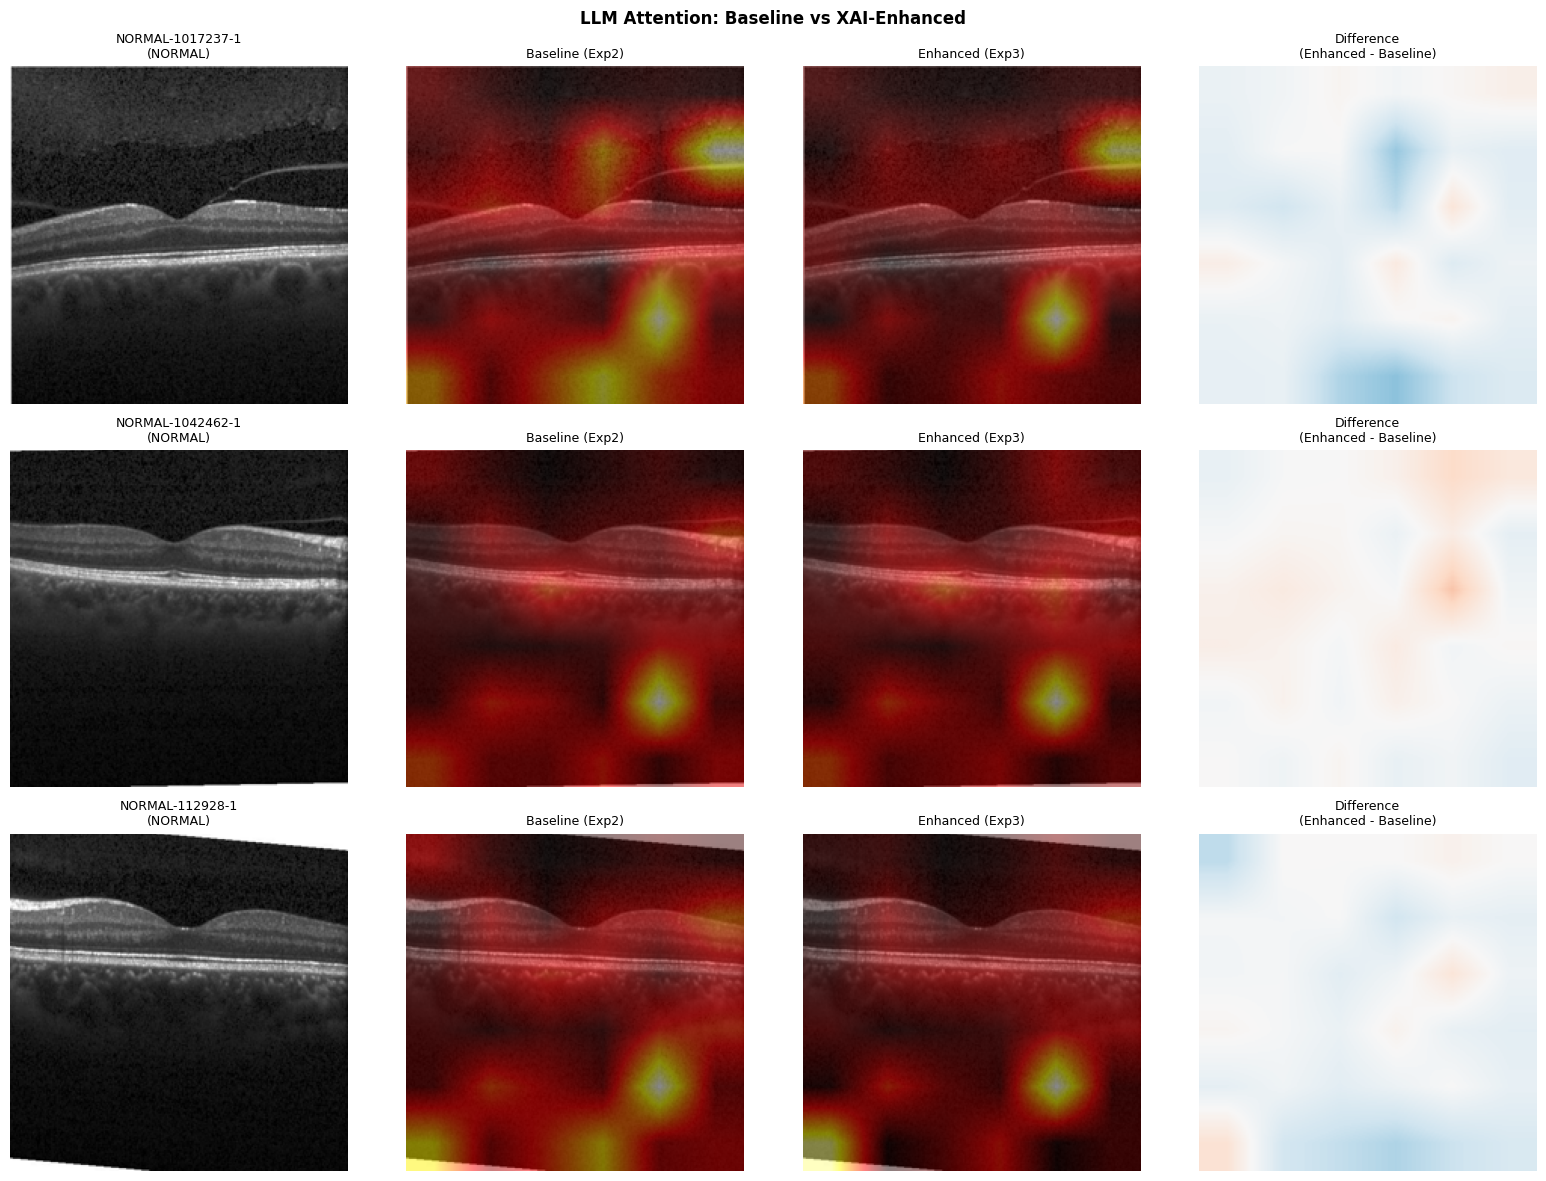

Comparison figure saved: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/comparison_llm_attention_baseline_vs_enhanced.png

 실험 3 완료!
 Enhanced 추론: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/enhanced_results.json
 ResNet XAI:    /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/xai_resnet/
 LLM Attention: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/xai_attention/
 비교 분석:     /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/comparison_*.png


In [10]:
# =====================================================
# Baseline (Exp2) vs Enhanced (Exp3) LLM Attention 비교
# =====================================================

EXP2_ATTN_DIR = os.path.join(EXP_DIR, "exp2_outputs/xai_attention")
EXP3_ATTN_DIR = os.path.join(OUTPUT_DIR, "xai_attention")

# 공통 이미지 찾기 (npy 파일 기준)
exp2_npys = {os.path.basename(f).replace("_llm_attention.npy", ""): f
             for f in glob(os.path.join(EXP2_ATTN_DIR, "*_llm_attention.npy"))}
exp3_npys = {os.path.basename(f).replace("_llm_attention.npy", ""): f
             for f in glob(os.path.join(EXP3_ATTN_DIR, "*_llm_attention.npy"))}

common = sorted(set(exp2_npys.keys()) & set(exp3_npys.keys()))
print(f"Common images for comparison: {len(common)}")

if common:
    n_compare = min(5, len(common))
    fig, axes = plt.subplots(n_compare, 4, figsize=(16, 4 * n_compare))
    if n_compare == 1:
        axes = axes[np.newaxis, :]

    for i, name in enumerate(common[:n_compare]):
        # 원본 이미지 찾기
        entry = next((e for e in xai_mapping if os.path.splitext(e["image"])[0] == name), None)
        if entry:
            img_path = os.path.join(DATA_DIR, "test", entry["true_label"], entry["image"])
            display_img = np.array(Image.open(img_path).convert("L").resize((224, 224)))
            cls_label = entry["true_label"]
        else:
            display_img = np.zeros((224, 224))
            cls_label = "?"

        attn_baseline = np.load(exp2_npys[name])
        attn_enhanced = np.load(exp3_npys[name])

        # 업스케일
        attn_b_up = np.array(Image.fromarray(attn_baseline.astype(np.float32)).resize((224, 224), Image.BILINEAR))
        attn_e_up = np.array(Image.fromarray(attn_enhanced.astype(np.float32)).resize((224, 224), Image.BILINEAR))

        # 차이 맵
        diff_map = attn_e_up - attn_b_up

        axes[i, 0].imshow(display_img, cmap="gray")
        axes[i, 0].set_title(f"{name}\n({cls_label})", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(display_img, cmap="gray")
        axes[i, 1].imshow(attn_b_up, cmap="hot", alpha=0.5)
        axes[i, 1].set_title("Baseline (Exp2)", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(display_img, cmap="gray")
        axes[i, 2].imshow(attn_e_up, cmap="hot", alpha=0.5)
        axes[i, 2].set_title("Enhanced (Exp3)", fontsize=9)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(diff_map, cmap="RdBu_r", vmin=-1, vmax=1)
        axes[i, 3].set_title("Difference\n(Enhanced - Baseline)", fontsize=9)
        axes[i, 3].axis("off")

    plt.suptitle("LLM Attention: Baseline vs XAI-Enhanced", fontsize=12, fontweight="bold")
    plt.tight_layout()
    compare_path = os.path.join(OUTPUT_DIR, "comparison_llm_attention_baseline_vs_enhanced.png")
    plt.savefig(compare_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Comparison figure saved: {compare_path}")
else:
    print("No common images found. Run Experiment 2's LLM attention cell first.")

# --- 최종 실험 로그 업데이트 ---
log = {
    "experiment": "exp3_xai_enhanced",
    "method": "method1_dequantized",
    "xai_method_from_exp1": XAI_METHOD_TO_USE,
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "total_images_inference": len(results_enhanced),
    "total_images_xai": len(xai_results_exp3),
    "xai_types": ["resnet_gradcam", "llm_attention"],
    "comparison_with_exp2": len(common),
    "avg_words": round(np.mean([r["n_words"] for r in results_enhanced]), 1) if results_enhanced else 0,
}
with open(os.path.join(OUTPUT_DIR, "experiment_log.json"), "w") as f:
    json.dump(log, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f" 실험 3 완료!")
print(f" Enhanced 추론: {OUTPUT_DIR}/enhanced_results.json")
print(f" ResNet XAI:    {OUTPUT_DIR}/xai_resnet/")
print(f" LLM Attention: {OUTPUT_DIR}/xai_attention/")
print(f" 비교 분석:     {OUTPUT_DIR}/comparison_*.png")
print(f"{'='*60}")

## 10. IRB 평가: IoU & Pointing Game (해석 가능성 정량 평가)

**IRB 요구사항:**
> LLM이 생성한 Attention 히트맵과 Ground Truth Mask 간의 IoU 및 Pointing Game 정확도를 측정.
> Setting A와 B의 IoU 차이를 paired t-test로 비교.

**현재 구현:**
- Ground Truth Mask가 아직 없으므로, 실험 1의 GradCAM을 pseudo-GT로 사용
- 향후 전문의 어노테이션이 제공되면 `GT_MASK_DIR`을 설정하여 실제 GT 사용

In [11]:
# =====================================================
# IRB 평가: IoU & Pointing Game
# =====================================================
from scipy import stats

# Ground Truth 설정
# 향후: 전문의 어노테이션 마스크 경로
GT_MASK_DIR = None  # e.g., "/path/to/expert_annotations/"
# 현재: Exp1 GradCAM을 pseudo-GT로 사용
USE_GRADCAM_AS_GT = True

def compute_iou(map_a, map_b, threshold=0.5):
    """두 히트맵 간의 IoU (Intersection over Union)"""
    mask_a = map_a > threshold
    mask_b = map_b > threshold
    intersection = (mask_a & mask_b).sum()
    union = (mask_a | mask_b).sum()
    return float(intersection / union) if union > 0 else 0.0

def pointing_game(attention_map, ground_truth_map, threshold=0.5):
    """Pointing Game: attention 최대 활성화 위치가 GT 영역 내에 있는지"""
    gt_mask = ground_truth_map > threshold
    max_pos = np.unravel_index(attention_map.argmax(), attention_map.shape)
    return 1.0 if gt_mask[max_pos] else 0.0

def load_and_resize_map(npy_path, target_size=224):
    """히트맵을 로드하고 동일 크기로 리사이즈"""
    m = np.load(npy_path)
    m_resized = np.array(Image.fromarray(m.astype(np.float32)).resize(
        (target_size, target_size), Image.BILINEAR))
    if m_resized.max() > m_resized.min():
        m_resized = (m_resized - m_resized.min()) / (m_resized.max() - m_resized.min())
    return m_resized

# Setting A (Exp2) vs Setting B (Exp3) Attention → GT(GradCAM) IoU 비교
EXP2_ATTN_DIR = os.path.join(EXP_DIR, "exp2_outputs/xai_attention")
EXP3_ATTN_DIR = os.path.join(OUTPUT_DIR, "xai_attention")

exp2_npys = {os.path.basename(f).replace("_llm_attention.npy", ""): f
             for f in glob(os.path.join(EXP2_ATTN_DIR, "*_llm_attention.npy"))}
exp3_npys = {os.path.basename(f).replace("_llm_attention.npy", ""): f
             for f in glob(os.path.join(EXP3_ATTN_DIR, "*_llm_attention.npy"))}

common_imgs = sorted(set(exp2_npys.keys()) & set(exp3_npys.keys()))
print(f"Common images for IoU/Pointing Game: {len(common_imgs)}")

iou_results = []
for name in common_imgs:
    # GT: Exp1 GradCAM (pseudo-GT)
    entry = next((e for e in xai_mapping if os.path.splitext(e["image"])[0] == name), None)
    if not entry:
        continue
    gt_npy = os.path.join(EXP1_XAI_DIR, XAI_METHOD_TO_USE,
                          entry["xai_files"][XAI_METHOD_TO_USE].replace(".png", ".npy"))
    if not os.path.exists(gt_npy):
        continue

    gt_map = load_and_resize_map(gt_npy)
    attn_a = load_and_resize_map(exp2_npys[name])  # Setting A
    attn_b = load_and_resize_map(exp3_npys[name])  # Setting B

    iou_a = compute_iou(attn_a, gt_map)
    iou_b = compute_iou(attn_b, gt_map)
    pg_a = pointing_game(attn_a, gt_map)
    pg_b = pointing_game(attn_b, gt_map)
    corr_ab = float(np.corrcoef(attn_a.flatten(), attn_b.flatten())[0, 1])

    iou_results.append({
        "image": name, "class": entry["true_label"],
        "iou_setting_a": iou_a, "iou_setting_b": iou_b, "iou_diff": iou_b - iou_a,
        "pg_setting_a": pg_a, "pg_setting_b": pg_b,
        "corr_a_b": corr_ab,
    })

if iou_results:
    df_iou = pd.DataFrame(iou_results)

    print(f"\n{'='*70}")
    print(f" IoU & Pointing Game: Setting A vs Setting B (N={len(iou_results)})")
    print(f"{'='*70}")
    print(f"  GT source: {'Exp1 GradCAM (pseudo-GT)' if USE_GRADCAM_AS_GT else GT_MASK_DIR}")
    print(f"\n{'Image':<30s} {'IoU_A':>6s} {'IoU_B':>6s} {'Diff':>7s} {'PG_A':>5s} {'PG_B':>5s} {'Corr':>6s}")
    print("-" * 70)
    for r in iou_results:
        print(f"  {r['image']:<28s} {r['iou_setting_a']:>6.3f} {r['iou_setting_b']:>6.3f} "
              f"{r['iou_diff']:>+7.3f} {r['pg_setting_a']:>5.1f} {r['pg_setting_b']:>5.1f} "
              f"{r['corr_a_b']:>6.3f}")

    # 집계 통계
    print(f"\n  Mean IoU  Setting A: {df_iou['iou_setting_a'].mean():.4f} ± {df_iou['iou_setting_a'].std():.4f}")
    print(f"  Mean IoU  Setting B: {df_iou['iou_setting_b'].mean():.4f} ± {df_iou['iou_setting_b'].std():.4f}")
    print(f"  Mean PG   Setting A: {df_iou['pg_setting_a'].mean():.4f}")
    print(f"  Mean PG   Setting B: {df_iou['pg_setting_b'].mean():.4f}")
    print(f"  Mean Corr A↔B:       {df_iou['corr_a_b'].mean():.4f}")

    # Paired t-test (IRB 요구)
    if len(iou_results) >= 2:
        t_stat, p_value = stats.ttest_rel(df_iou['iou_setting_a'], df_iou['iou_setting_b'])
        print(f"\n  Paired t-test (IoU): t={t_stat:.4f}, p={p_value:.4f}")
        print(f"  {'유의미함 (p<0.05)' if p_value < 0.05 else '유의미하지 않음 (p>=0.05)'}")

    # 저장
    df_iou.to_csv(os.path.join(OUTPUT_DIR, "iou_pointing_game_results.csv"), index=False)
    with open(os.path.join(OUTPUT_DIR, "iou_pointing_game_results.json"), "w") as f:
        json.dump(iou_results, f, indent=2)
    print(f"\n  Results saved to {OUTPUT_DIR}/iou_pointing_game_results.*")
else:
    print("IoU 비교 불가: 공통 이미지 없음. 실험 2의 LLM Attention을 먼저 실행하세요.")

Common images for IoU/Pointing Game: 3

 IoU & Pointing Game: Setting A vs Setting B (N=3)
  GT source: Exp1 GradCAM (pseudo-GT)

Image                           IoU_A  IoU_B    Diff  PG_A  PG_B   Corr
----------------------------------------------------------------------
  NORMAL-1017237-1              0.001  0.000  -0.001   0.0   0.0  0.884
  NORMAL-1042462-1              0.000  0.002  +0.002   0.0   0.0  0.903
  NORMAL-112928-1               0.000  0.000  +0.000   0.0   0.0  0.870

  Mean IoU  Setting A: 0.0004 ± 0.0006
  Mean IoU  Setting B: 0.0007 ± 0.0012
  Mean PG   Setting A: 0.0000
  Mean PG   Setting B: 0.0000
  Mean Corr A↔B:       0.8857

  Paired t-test (IoU): t=-0.3787, p=0.7413
  유의미하지 않음 (p>=0.05)

  Results saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/iou_pointing_game_results.*


## 11. IRB 평가: 환각(Hallucination) 감소율

**IRB 요구사항:**
> 모델이 존재하지 않는 병변이나 잘못된 근거를 바탕으로 예측을 수행하는 비율(False Positive Rate)을 측정하여,
> XAI 히트맵 주입 시 환각이 통계적으로 유의미하게 감소하는지 검증.

**측정 방법:**
- NORMAL 이미지에서 병리학적 키워드(CNV, drusen, fluid, edema 등)가 언급되면 = 환각
- CNV 이미지에서 "normal", "healthy"가 언급되면 = 환각
- Setting A vs B의 환각률 비교

In [12]:
# =====================================================
# IRB 평가: 환각(Hallucination) 감소율 분석
# =====================================================

# 환각 판정 키워드 정의
# NORMAL 이미지에서 이 키워드가 나오면 = 거짓양성 (환각)
PATHOLOGY_KEYWORDS = [
    "cnv", "choroidal neovascularization", "neovascular",
    "drusen", "fluid", "subretinal fluid", "intraretinal fluid",
    "edema", "macular edema", "cystoid",
    "PED", "pigment epithelial detachment",
    "atrophy", "geographic atrophy",
    "SHRM", "subretinal hyperreflective material",
    "hemorrhage", "exudation", "fibrosis",
]
# CNV 이미지에서 이 키워드만 나오면 = 거짓음성
NORMAL_KEYWORDS = ["normal", "healthy", "unremarkable", "no abnormality", "no pathology"]


def detect_hallucinations(response_text, true_class):
    """응답에서 환각(허위 병변 언급)을 감지합니다."""
    text_lower = response_text.lower()
    hallucinations = []

    if true_class == "NORMAL":
        for kw in PATHOLOGY_KEYWORDS:
            if kw.lower() in text_lower:
                hallucinations.append({"type": "false_positive", "keyword": kw})
    elif true_class == "CNV":
        # CNV인데 "정상"이라고만 하면 환각
        has_pathology = any(kw.lower() in text_lower for kw in PATHOLOGY_KEYWORDS)
        has_normal_only = any(kw.lower() in text_lower for kw in NORMAL_KEYWORDS) and not has_pathology
        if has_normal_only:
            hallucinations.append({"type": "false_negative", "keyword": "normal/healthy only"})

    return hallucinations


# Setting A (실험 2) 환각 분석
if os.path.exists(EXP2_RESULTS):
    with open(EXP2_RESULTS) as f:
        results_baseline = json.load(f)
else:
    results_baseline = []

# Setting B (실험 3) 환각 분석
hall_a, hall_b = [], []

# Setting A
for r in results_baseline:
    h = detect_hallucinations(r["response"], r["class"])
    hall_a.append({"image": r["image"], "class": r["class"],
                   "n_hallucinations": len(h), "details": h})

# Setting B
for r in results_enhanced:
    h = detect_hallucinations(r["response"], r["class"])
    hall_b.append({"image": r["image"], "class": r["class"],
                   "n_hallucinations": len(h), "details": h})

# 공통 이미지 비교
baseline_hall = {h["image"]: h for h in hall_a}
enhanced_hall = {h["image"]: h for h in hall_b}
common_hall = sorted(set(baseline_hall.keys()) & set(enhanced_hall.keys()))

print(f"{'='*70}")
print(f" 환각(Hallucination) 분석: Setting A vs Setting B")
print(f"{'='*70}")

# 전체 통계
for label, hall_list, setting in [("Setting A", hall_a, "Baseline"), ("Setting B", hall_b, "Enhanced")]:
    total = len(hall_list)
    with_hall = sum(1 for h in hall_list if h["n_hallucinations"] > 0)
    by_cls = {}
    for h in hall_list:
        cls = h["class"]
        if cls not in by_cls:
            by_cls[cls] = {"total": 0, "hallucinated": 0}
        by_cls[cls]["total"] += 1
        if h["n_hallucinations"] > 0:
            by_cls[cls]["hallucinated"] += 1
    print(f"\n  [{label} ({setting})] N={total}")
    print(f"    전체 환각률: {with_hall}/{total} ({with_hall/total*100:.1f}%)" if total > 0 else "    N/A")
    for cls, v in sorted(by_cls.items()):
        rate = v["hallucinated"] / v["total"] * 100 if v["total"] > 0 else 0
        print(f"    {cls}: {v['hallucinated']}/{v['total']} ({rate:.1f}%)")

# 공통 이미지 비교
if common_hall:
    print(f"\n  --- 공통 이미지 비교 (N={len(common_hall)}) ---")
    reduced, same, increased = 0, 0, 0
    for img in common_hall:
        h_a = baseline_hall[img]["n_hallucinations"]
        h_b = enhanced_hall[img]["n_hallucinations"]
        if h_b < h_a:
            reduced += 1
        elif h_b == h_a:
            same += 1
        else:
            increased += 1
    print(f"    환각 감소: {reduced} images")
    print(f"    변화 없음: {same} images")
    print(f"    환각 증가: {increased} images")

    hall_a_common = [baseline_hall[img]["n_hallucinations"] for img in common_hall]
    hall_b_common = [enhanced_hall[img]["n_hallucinations"] for img in common_hall]
    if len(common_hall) >= 2:
        t_stat, p_value = stats.ttest_rel(hall_a_common, hall_b_common)
        print(f"\n    Paired t-test (환각 수): t={t_stat:.4f}, p={p_value:.4f}")
        print(f"    {'유의미함 (p<0.05)' if p_value < 0.05 else '유의미하지 않음 (p>=0.05)'}")

# 저장
hallucination_summary = {
    "setting_a": {"total": len(hall_a),
                  "with_hallucination": sum(1 for h in hall_a if h["n_hallucinations"] > 0)},
    "setting_b": {"total": len(hall_b),
                  "with_hallucination": sum(1 for h in hall_b if h["n_hallucinations"] > 0)},
    "common_comparison": {"n_common": len(common_hall),
                          "reduced": reduced if common_hall else 0,
                          "same": same if common_hall else 0,
                          "increased": increased if common_hall else 0},
    "details_a": hall_a,
    "details_b": hall_b,
}
with open(os.path.join(OUTPUT_DIR, "hallucination_analysis.json"), "w") as f:
    json.dump(hallucination_summary, f, indent=2, ensure_ascii=False)
print(f"\n  Results saved to {OUTPUT_DIR}/hallucination_analysis.json")

 환각(Hallucination) 분석: Setting A vs Setting B

  [Setting A (Baseline)] N=50
    전체 환각률: 25/50 (50.0%)
    CNV: 0/25 (0.0%)
    NORMAL: 25/25 (100.0%)

  [Setting B (Enhanced)] N=100
    전체 환각률: 48/100 (48.0%)
    CNV: 0/50 (0.0%)
    NORMAL: 48/50 (96.0%)

  --- 공통 이미지 비교 (N=12) ---
    환각 감소: 4 images
    변화 없음: 8 images
    환각 증가: 0 images

    Paired t-test (환각 수): t=2.1589, p=0.0538
    유의미하지 않음 (p>=0.05)

  Results saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/hallucination_analysis.json


## 12. 종합 실험 요약 & 로그

Setting A (실험 2) vs Setting B (실험 3) 전체 결과를 정리하고 실험 로그를 저장합니다.

In [13]:
# =====================================================
# 종합 실험 요약
# =====================================================

print("=" * 70)
print(" IRB 실험 프로토콜 결과 종합")
print("=" * 70)

print(f"\n[1] 실험 구성")
print(f"  Setting A (Exp2): 원본 OCT + 기본 query")
print(f"  Setting B (Exp3): 오버레이 OCT ({OVERLAY_METHOD}, α={OVERLAY_ALPHA}) + Enhanced query")
print(f"  XAI source: Exp1 {XAI_METHOD_TO_USE}")

print(f"\n[2] 추론 결과")
if results_baseline:
    print(f"  Setting A: {len(results_baseline)} images, avg {np.mean([r['n_words'] for r in results_baseline]):.1f} words")
print(f"  Setting B: {len(results_enhanced)} images, avg {np.mean([r['n_words'] for r in results_enhanced]):.1f} words")

if iou_results:
    print(f"\n[3] IoU & Pointing Game (N={len(iou_results)})")
    print(f"  IoU  Setting A: {np.mean([r['iou_setting_a'] for r in iou_results]):.4f}")
    print(f"  IoU  Setting B: {np.mean([r['iou_setting_b'] for r in iou_results]):.4f}")
    print(f"  PG   Setting A: {np.mean([r['pg_setting_a'] for r in iou_results]):.4f}")
    print(f"  PG   Setting B: {np.mean([r['pg_setting_b'] for r in iou_results]):.4f}")

print(f"\n[4] 환각 분석")
if hall_a:
    rate_a = sum(1 for h in hall_a if h["n_hallucinations"]>0) / len(hall_a) * 100
    print(f"  Setting A 환각률: {rate_a:.1f}%")
if hall_b:
    rate_b = sum(1 for h in hall_b if h["n_hallucinations"]>0) / len(hall_b) * 100
    print(f"  Setting B 환각률: {rate_b:.1f}%")

print(f"\n[5] 향후 작업 (병원 데이터 수령 시)")
print(f"  - CLASS_NAMES를 ['Responder', 'Non-responder']로 변경")
print(f"  - DATA_DIR을 병원 OCT 데이터 경로로 변경")
print(f"  - GT_MASK_DIR에 전문의 어노테이션 마스크 경로 설정")
print(f"  - OVERLAY_ALPHA 최적값 탐색 (ablation study)")

# 실험 로그 저장
log = {
    "experiment": "exp3_setting_b",
    "irb_protocol": "Setting B (XAI-Guided)",
    "method": "method1_dequantized",
    "overlay_method": OVERLAY_METHOD,
    "overlay_alpha": OVERLAY_ALPHA,
    "xai_method_from_exp1": XAI_METHOD_TO_USE,
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "total_images_inference": len(results_enhanced),
    "total_images_xai": len(xai_results_exp3),
    "xai_types": ["resnet_gradcam", "llm_attention"],
    "avg_words": round(np.mean([r["n_words"] for r in results_enhanced]), 1),
    "evaluation": {
        "iou_pointing_game": len(iou_results) if iou_results else 0,
        "hallucination_analysis": len(hall_b),
    },
}
with open(os.path.join(OUTPUT_DIR, "experiment_log.json"), "w") as f:
    json.dump(log, f, indent=2, ensure_ascii=False)

print(f"\n{'='*70}")
print(f" 실험 3 완료!")
print(f" 오버레이 이미지:   {OUTPUT_DIR}/overlaid_images/")
print(f" Enhanced 추론:     {OUTPUT_DIR}/enhanced_results.json")
print(f" ResNet XAI:        {OUTPUT_DIR}/xai_resnet/")
print(f" LLM Attention:     {OUTPUT_DIR}/xai_attention/")
print(f" IoU/Pointing Game: {OUTPUT_DIR}/iou_pointing_game_results.*")
print(f" 환각 분석:         {OUTPUT_DIR}/hallucination_analysis.json")
print(f" 비교 시각화:       {OUTPUT_DIR}/comparison_*.png")
print(f"{'='*70}")

 IRB 실험 프로토콜 결과 종합

[1] 실험 구성
  Setting A (Exp2): 원본 OCT + 기본 query
  Setting B (Exp3): 오버레이 OCT (spatial_overlay, α=0.4) + Enhanced query
  XAI source: Exp1 gradcam

[2] 추론 결과
  Setting A: 50 images, avg 61.0 words
  Setting B: 100 images, avg 104.6 words

[3] IoU & Pointing Game (N=3)
  IoU  Setting A: 0.0004
  IoU  Setting B: 0.0007
  PG   Setting A: 0.0000
  PG   Setting B: 0.0000

[4] 환각 분석
  Setting A 환각률: 50.0%
  Setting B 환각률: 48.0%

[5] 향후 작업 (병원 데이터 수령 시)
  - CLASS_NAMES를 ['Responder', 'Non-responder']로 변경
  - DATA_DIR을 병원 OCT 데이터 경로로 변경
  - GT_MASK_DIR에 전문의 어노테이션 마스크 경로 설정
  - OVERLAY_ALPHA 최적값 탐색 (ablation study)

 실험 3 완료!
 오버레이 이미지:   /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/overlaid_images/
 Enhanced 추론:     /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/enhanced_results.json
 ResNet XAI:        /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp3_outputs/xai_resnet/
 LLM Attention:     /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experim